In [1]:
#| default_exp _trainer

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#| export
import torch
import matplotlib.pyplot as plt
from dreamer4._core import build_tiny_pinpad_dataset, make_tiny_dataloader
from dreamer4.dreamer4 import VideoTokenizer, DynamicsWorldModel
from dreamer4.trainers import VideoTokenizerTrainer, SimTrainer, cycle

/home/j/workspace/dreamer4/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
CPU = False
device = 'cuda' if not CPU else 'cpu'
dataset, env = build_tiny_pinpad_dataset(device=device, episode_length=30)

pads {'3', '1', '2'} target ('1', '2', '3')

Built tiny PinPad dataset with 34 videos of shape torch.Size([3, 30, 64, 64]) - (c, t, h, w). Success rate 0.0%


In [5]:
tiny_loader = make_tiny_dataloader(dataset, n_items=1024, batch_size=16)
lpips_loss = 0.05
dim, dim_latent = 64, 64
tokenizer = VideoTokenizer(
    dim=dim,#16,
    # encoder_depth = 1, # I think the paper has a different depths and does the time blocks every n (8?) layers
    # decoder_depth = 1,
    # time_block_every = 1,
    dim_latent = dim_latent, #16,
    patch_size = 16, #32
    attn_dim_head = 16,
    num_latent_tokens = 4,
    lpips_loss_weight=lpips_loss,
).to(device)

world_model_and_policy = DynamicsWorldModel(
    video_tokenizer = tokenizer,
    dim = dim, #16,
    dim_latent = dim_latent, #16,
    max_steps = 64,
    num_tasks = 1,
    num_latent_tokens = 4, #1,
    # depth = 1,
    # time_block_every = 1,
    # num_spatial_tokens = 1,
    pred_orig_latent = True,
    num_discrete_actions = env.action_space.n,
    attn_dim_head = 16,
    prob_no_shortcut_train = 0.1,
    num_residual_streams = 1
).to(device)

In [6]:
wm_trainer = VideoTokenizerTrainer(
    model = tokenizer,
    dataset = dataset,
    cpu = CPU,
    num_train_steps=30
)

losses = wm_trainer.forward()

WM trained for 29 steps. mean loss 0.7054987887541453


In [7]:
trainer = SimTrainer(
    world_model_and_policy,
    batch_size = 32,
    cpu = CPU
)
trainer(env, num_episodes = 1, env_is_vectorized = False)

policy head loss: -0.016 | value head loss: 5.668
policy head loss: -0.025 | value head loss: 5.567
training complete
total reward from collected experiences: 0.050


W1104 17:03:17.456000 339952 torch/_dynamo/convert_frame.py:964] [0/8] torch._dynamo hit config.recompile_limit (8)
W1104 17:03:17.456000 339952 torch/_dynamo/convert_frame.py:964] [0/8]    function: 'flex_attention' (/home/j/workspace/dreamer4/.venv/lib/python3.10/site-packages/torch/nn/attention/flex_attention.py:1161)
W1104 17:03:17.456000 339952 torch/_dynamo/convert_frame.py:964] [0/8]    last reason: 0/7: ___check_obj_id(block_mask.mask_mod.__code__, 135125662323216)
W1104 17:03:17.456000 339952 torch/_dynamo/convert_frame.py:964] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1104 17:03:17.456000 339952 torch/_dynamo/convert_frame.py:964] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


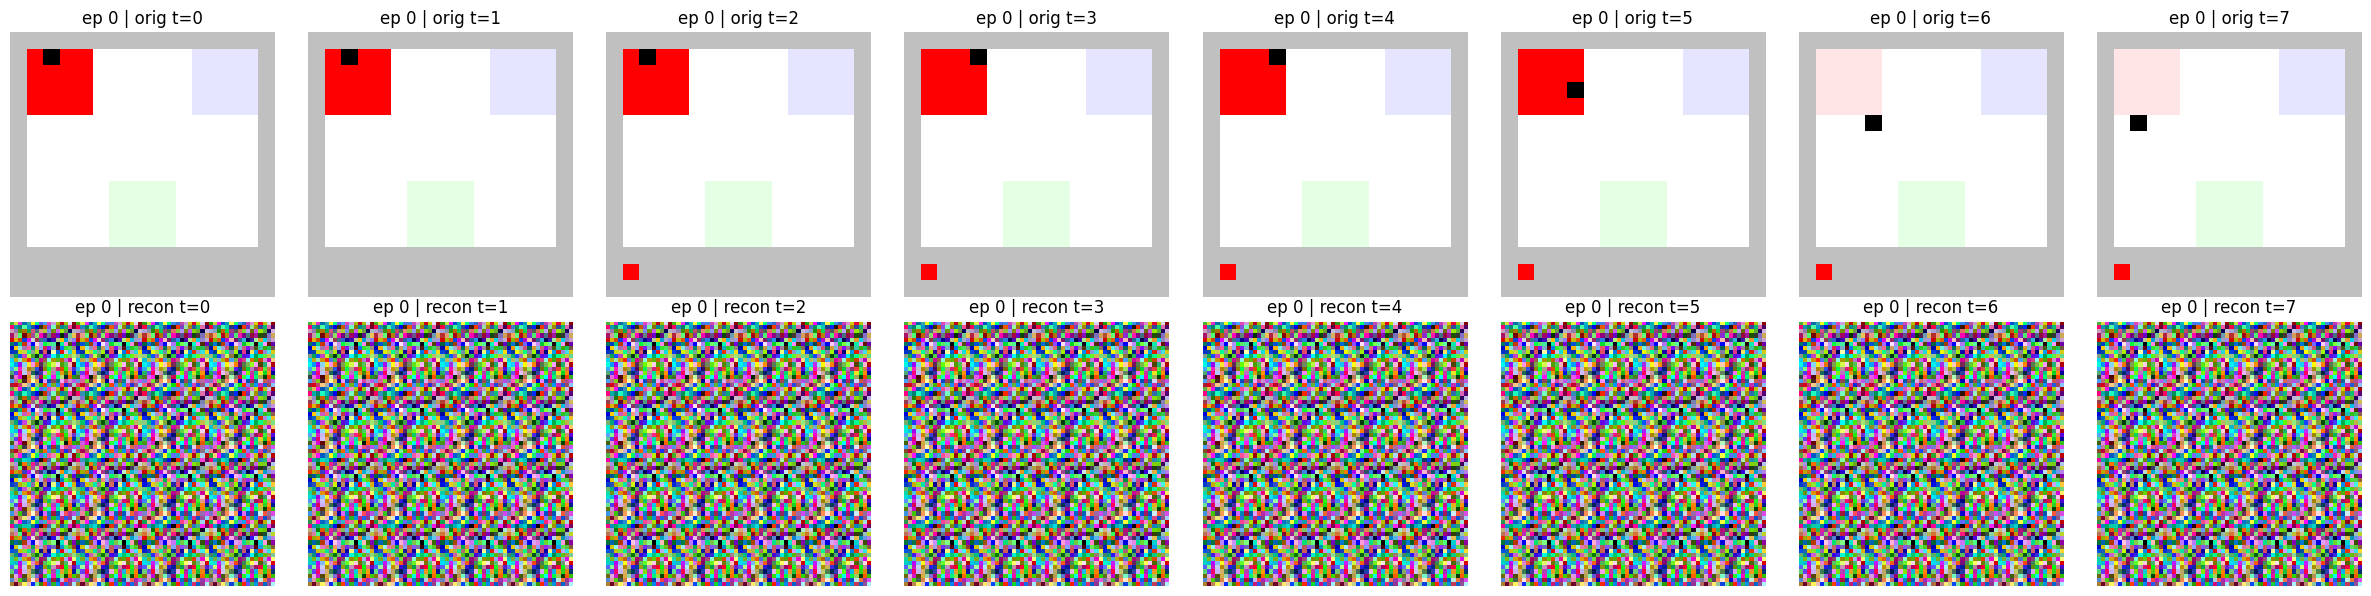

[Experience(latents=tensor([[[[-0.6343, -0.1465,  0.2511,  ..., -0.4857, -0.5967,  0.0588],
           [-0.5685, -0.2230,  0.1841,  ..., -0.5534, -0.5791,  0.0756],
           [-0.6731, -0.1076,  0.3881,  ..., -0.3817, -0.6604,  0.0958],
           [-0.5554, -0.1158,  0.1364,  ..., -0.5620, -0.5994,  0.1152]],
 
          [[-0.6343, -0.1465,  0.2511,  ..., -0.4857, -0.5967,  0.0588],
           [-0.5685, -0.2230,  0.1841,  ..., -0.5534, -0.5791,  0.0756],
           [-0.6731, -0.1076,  0.3881,  ..., -0.3817, -0.6604,  0.0958],
           [-0.5554, -0.1158,  0.1364,  ..., -0.5620, -0.5994,  0.1152]],
 
          [[-0.6347, -0.1453,  0.2506,  ..., -0.4854, -0.5977,  0.0582],
           [-0.5688, -0.2215,  0.1844,  ..., -0.5533, -0.5805,  0.0746],
           [-0.6733, -0.1065,  0.3879,  ..., -0.3815, -0.6612,  0.0950],
           [-0.5562, -0.1155,  0.1366,  ..., -0.5615, -0.6003,  0.1148]],
 
          ...,
 
          [[-0.6349, -0.1437,  0.2656,  ..., -0.4791, -0.6043,  0.0521],
      

In [8]:
trainer.eval_episodes(
    env=env,
    tokenizer=tokenizer,
    num_episodes=1,
    max_steps=30,
    env_is_vectorized=False,
    max_time_to_show=8,
)

In [9]:
ep_length = 100
dataset, env = build_tiny_pinpad_dataset(device=device, episode_length=ep_length, n=16384)

pretrain_steps = 5000
wm_pretrainer = VideoTokenizerTrainer(
    model = tokenizer,
    dataset = dataset,
    cpu = CPU,
    num_train_steps=pretrain_steps
)

wm_trainer = VideoTokenizerTrainer(
    model = tokenizer,
    dataset = dataset,
    cpu = CPU,
    num_train_steps=ep_length
)

trainer = SimTrainer(
    world_model_and_policy,
    batch_size = 32,
    cpu = CPU
)

pads {'3', '1', '2'} target ('1', '2', '3')

!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
!!!!SUCCESS!!!
Built tiny PinPad dataset with 163 videos of shape torch.Size([3, 100, 64, 64]) - (c, t, h, w). Success rate 7.4%


In [ ]:

# All together now
if debug:=True:
    epochs = 1
    pretrain=True; pretrain_eps=10; policy_pretrain_eps=2
    train_wm=True
else:
    epochs = 100
    pretrain=True; pretrain_eps=1000; policy_pretrain_eps=100
    train_wm=True

# Reset the policy
world_model_and_policy = DynamicsWorldModel(
    video_tokenizer = tokenizer,
    dim = dim, #16,
    dim_latent = dim_latent, #16,
    max_steps = 64,
    num_tasks = 1,
    num_latent_tokens = 4, #1,
    # depth = 1,
    # time_block_every = 1,
    # num_spatial_tokens = 1,
    pred_orig_latent = True,
    num_discrete_actions = env.action_space.n,
    attn_dim_head = 16,
    prob_no_shortcut_train = 0.1,
    num_residual_streams = 1
).to(device)

trainer = SimTrainer(
    world_model_and_policy,
    batch_size = 32,
    cpu = CPU,
    epochs=epochs,
)

for epoch in range(epochs):
    if pretrain:
        print(f'Initializing pretraining...')
        pretrain = False
        if train_wm: wm_pretrainer.forward()
        trainer(env, num_episodes=policy_pretrain_eps, max_experiences_before_learn=ep_length, env_is_vectorized = False)
    else:
        if train_wm: losses = wm_trainer.forward()
        trainer(env, num_episodes = 1, env_is_vectorized = False)

    if epoch % 10 == 0:
        trainer.eval_episodes(
            env=env,
            tokenizer=tokenizer,
            num_episodes=1,
            max_steps=ep_length,
            env_is_vectorized=False,
            max_time_to_show=8,
        )

Initializing pretraining...


In [ ]:
eval_exp = trainer.eval_episodes(
    env=env,
    tokenizer=tokenizer,
    num_episodes=10,
    max_steps=ep_length,
    env_is_vectorized=False,
    max_time_to_show=8,
    show=False,
)

In [ ]:
all_actions = [entry.actions[0].cpu().numpy()[0].squeeze() for entry in eval_exp]
all_rewards = [entry.rewards[0].cpu().numpy().squeeze() for entry in eval_exp]

In [ ]:
all_rewards

In [ ]:
import numpy as np
actions = np.concatenate(all_actions); actions.shape
rewards = np.concatenate(all_rewards); rewards.shape
# plt.hist(actions)
plt.hist(rewards)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()